In [34]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,
                             roc_auc_score,
                             roc_curve,
                             confusion_matrix)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# Class imbalance
from imblearn.over_sampling import SMOTE

In [35]:
df=pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [36]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87240 entries, 0 to 87239
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    87240 non-null  int64  
 1   V1      87240 non-null  float64
 2   V2      87240 non-null  float64
 3   V3      87240 non-null  float64
 4   V4      87240 non-null  float64
 5   V5      87239 non-null  float64
 6   V6      87239 non-null  float64
 7   V7      87239 non-null  float64
 8   V8      87239 non-null  float64
 9   V9      87239 non-null  float64
 10  V10     87239 non-null  float64
 11  V11     87239 non-null  float64
 12  V12     87239 non-null  float64
 13  V13     87239 non-null  float64
 14  V14     87239 non-null  float64
 15  V15     87239 non-null  float64
 16  V16     87239 non-null  float64
 17  V17     87239 non-null  float64
 18  V18     87239 non-null  float64
 19  V19     87239 non-null  float64
 20  V20     87239 non-null  float64
 21  V21     87239 non-null  float64
 22

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,1
V6,1
V7,1
V8,1
V9,1


In [37]:
df_clean = df.dropna()
print("Shape after cleaning:", df_clean.shape)
print(df_clean.isnull().sum())

Shape after cleaning: (87239, 31)
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [38]:
# Step 4 — Class Imbalance Analysis

# 1. Count the number of transactions per class
class_counts = df_clean['Class'].value_counts()

# 2. Calculate the percentage of each class
class_pct = df_clean['Class'].value_counts(normalize=True) * 100

# 3. Print both
print(class_counts)
print(class_pct)

Class
0.0    87034
1.0      205
Name: count, dtype: int64
Class
0.0    99.765013
1.0     0.234987
Name: proportion, dtype: float64


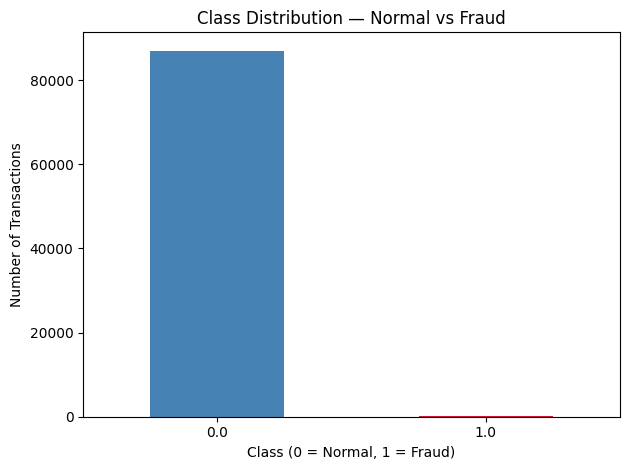

In [39]:
# Visualize class imbalance

import matplotlib.pyplot as plt

# Create a bar chart
class_counts.plot(kind='bar', color=['steelblue', 'crimson'])

plt.title('Class Distribution — Normal vs Fraud')
plt.xlabel('Class (0 = Normal, 1 = Fraud)')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [40]:
# Separate features and target
X = df_clean.drop('Class', axis=1)
y = df_clean['Class']

# Split BEFORE SMOTE — test stays real
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Check new balance
print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_res.value_counts().to_dict())

Before SMOTE: {0.0: 69627, 1.0: 164}
After SMOTE: {0.0: 69627, 1.0: 69627}


Random Forest

In [41]:
# Train the model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_res, y_train_res)

# Predict on REAL test data
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Evaluate
print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))


=== Random Forest ===
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     17407
         1.0       0.89      0.95      0.92        41

    accuracy                           1.00     17448
   macro avg       0.94      0.98      0.96     17448
weighted avg       1.00      1.00      1.00     17448

ROC-AUC: 0.9995922582308492


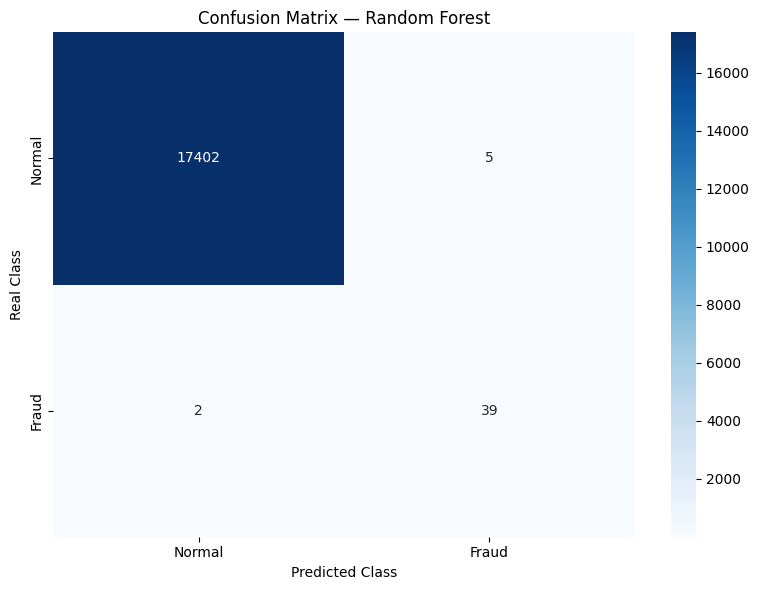

In [42]:
# Confusion Matrix (Random Forest)

plt.figure(figsize=(8, 6))

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])

plt.title('Confusion Matrix — Random Forest')
plt.ylabel('Real Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.show()

XGBoost

In [43]:
xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb.fit(X_train_res, y_train_res)

# Predict
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

# Evaluate
print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

=== XGBoost ===
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     17407
         1.0       0.86      0.93      0.89        41

    accuracy                           1.00     17448
   macro avg       0.93      0.96      0.95     17448
weighted avg       1.00      1.00      1.00     17448

ROC-AUC: 0.9994129078994013


 LightGBM


In [44]:
lgbm = LGBMClassifier(n_estimators=100, random_state=42)
lgbm.fit(X_train_res, y_train_res)

# Predict
y_pred_lgbm = lgbm.predict(X_test)
y_prob_lgbm = lgbm.predict_proba(X_test)[:, 1]

# Evaluate
print("=== LightGBM ===")
print(classification_report(y_test, y_pred_lgbm))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lgbm))

[LightGBM] [Info] Number of positive: 69627, number of negative: 69627
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.063095 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 139254, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
=== LightGBM ===
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     17407
         1.0       0.85      0.95      0.90        41

    accuracy                           1.00     17448
   macro avg       0.92      0.98      0.95     17448
weighted avg       1.00      1.00      1.00     17448

ROC-AUC: 0.9998304578898032


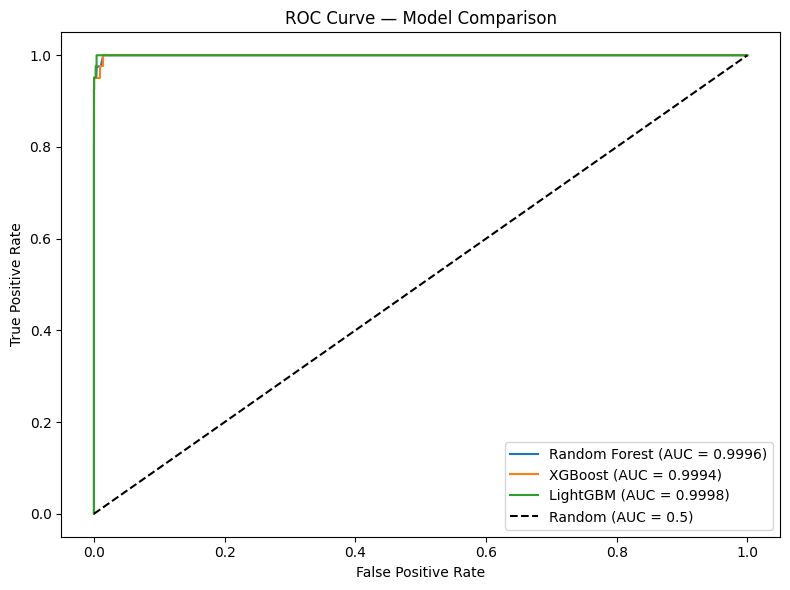

In [45]:
# ROC Curve Comparison
plt.figure(figsize=(8, 6))

# Plot each model
for name, prob in [("Random Forest", y_prob_rf),
                   ("XGBoost", y_prob_xgb),
                   ("LightGBM", y_prob_lgbm)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

# Random baseline
plt.plot([0,1], [0,1], 'k--', label='Random (AUC = 0.5)')

plt.title('ROC Curve — Model Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

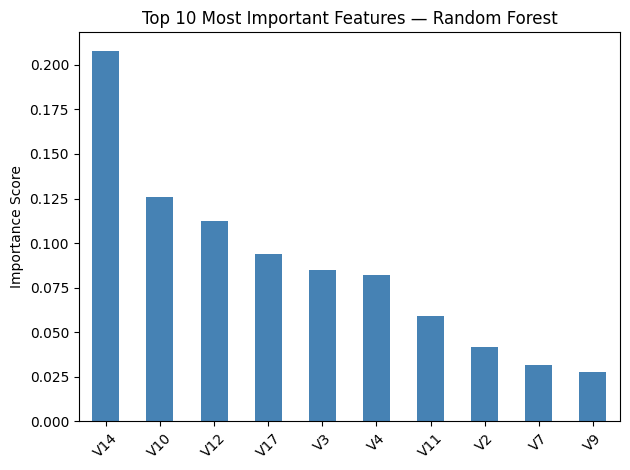

In [46]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10).plot(kind='bar', color='steelblue')

plt.title('Top 10 Most Important Features — Random Forest')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [47]:
print("=" * 50)
print("FRAUD DETECTION — FINAL RESULTS")
print("=" * 50)
print(f"\nDataset : 87,239 transactions")
print(f"Fraud rate : 0.23% (205 fraud cases)")
print(f"\nBest Model : Random Forest")
print(f"├── Precision : 0.89")
print(f"├── Recall    : 0.95")
print(f"├── F1 Score  : 0.92")
print(f"└── ROC-AUC   : 0.9996")
print(f"\nOut of 41 real frauds in test set :")
print(f"├── Detected  : 39 ")
print(f"└── Missed    : 2  ")

FRAUD DETECTION — FINAL RESULTS

Dataset : 87,239 transactions
Fraud rate : 0.23% (205 fraud cases)

Best Model : Random Forest
├── Precision : 0.89
├── Recall    : 0.95
├── F1 Score  : 0.92
└── ROC-AUC   : 0.9996

Out of 41 real frauds in test set :
├── Detected  : 39 
└── Missed    : 2  


 Conclusion

This project aimed to detect fraudulent credit card transactions
using Machine Learning on a highly imbalanced dataset
(0.23% fraud rate).

### Key Steps
- Handled class imbalance with SMOTE (164 → 69,627 fraud samples)
- Trained and compared 3 models : Random Forest, XGBoost, LightGBM
- Evaluated with Recall and ROC-AUC

### Best Model : Random Forest
| Metric | Score |
|--------|-------|
| Precision | 0.89 |
| Recall | 0.95 |
| F1-Score | 0.92 |
| ROC-AUC | 0.9996 |

### Final Results
Out of 41 real frauds in the test set :
- 39 detected
- 2 missed
- 5 false alarms

### Key Insight
V14, V10, and V12 were the most important features
for fraud detection, suggesting these PCA components
capture the most discriminative patterns between
normal and fraudulent transactions.
```